In [1]:
import importlib.util, subprocess, sys
if importlib.util.find_spec('pyspark') is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pyspark', 'pyarrow'], check=True)
import pyspark; print('pyspark', pyspark.__version__)

pyspark 4.0.4


# Integrated CA1: NYC Taxi Fare Prediction with PySpark Data Lake + Neural Networks

This notebook merges Stages 1-6 in order. Run all cells top to bottom (Colab recommended). Stage notebooks live in `notebooks/` with the Git history.


# Stage 1: Data Ingestion and Big Data Storage
**Goal:** download NYC TLC Yellow Taxi data, load it with PySpark, and store it in a partitioned Parquet data lake (raw and curated zones).

**Why Parquet + partitioning?** Parquet is columnar and compressed, so Spark reads only the columns it needs. Partitioning by month lets queries skip irrelevant files.

In [2]:
import os, requests
from pathlib import Path

BASE = Path('..') if Path('../data').exists() else Path('.')
RAW = BASE / 'data' / 'raw'
LAKE = BASE / 'data' / 'lake'
RAW.mkdir(parents=True, exist_ok=True)
LAKE.mkdir(parents=True, exist_ok=True)

YEAR = 2024
MONTHS = [1, 2, 3]   # change/add months to scale the dataset up
URL = 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{y}-{m:02d}.parquet'
ZONES_URL = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'

## 1. Download raw files

In [3]:
def download(url, dest):
    if dest.exists():
        print('exists:', dest.name); return
    r = requests.get(url, stream=True, timeout=120)
    r.raise_for_status()
    with open(dest, 'wb') as f:
        for chunk in r.iter_content(chunk_size=1 << 20):
            f.write(chunk)
    print('downloaded:', dest.name, round(dest.stat().st_size / 1e6, 1), 'MB')

for m in MONTHS:
    download(URL.format(y=YEAR, m=m), RAW / f'yellow_tripdata_{YEAR}-{m:02d}.parquet')
download(ZONES_URL, RAW / 'taxi_zone_lookup.csv')

downloaded: yellow_tripdata_2024-01.parquet 50.0 MB
downloaded: yellow_tripdata_2024-02.parquet 50.3 MB
downloaded: yellow_tripdata_2024-03.parquet 60.1 MB
downloaded: taxi_zone_lookup.csv 0.0 MB


## 2. Start Spark (local mode)

In [4]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName('nyc-taxi-stage1')
         .master('local[*]')
         .config('spark.driver.memory', '4g')
         .config('spark.sql.shuffle.partitions', '16')
         .getOrCreate())
print('Spark', spark.version)

Spark 4.0.4


## 3. Load raw data and inspect

In [5]:
raw_files = [str(RAW / f'yellow_tripdata_{YEAR}-{m:02d}.parquet') for m in MONTHS]
df = spark.read.parquet(*raw_files)
df.printSchema()
n_rows = df.count()
print('rows:', n_rows, '| columns:', len(df.columns))
df.show(5, truncate=False)

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)

rows: 9554778 | columns: 19
+--------+--------------------+---------------------+---------------+-------------+----------+---

## 4. Dataset characteristics (for the report)

In [6]:
total_bytes = sum(os.path.getsize(f) for f in raw_files)
print('Raw size on disk (compressed Parquet): %.1f MB' % (total_bytes / 1e6))

nulls = df.select([F.sum(F.col(c).isNull().cast('int')).alias(c) for c in df.columns]).toPandas().T
nulls.columns = ['null_count']
nulls['null_pct'] = (nulls['null_count'] / n_rows * 100).round(2)
nulls

Raw size on disk (compressed Parquet): 160.4 MB


,null_count,null_pct
VendorID,0,0.00
tpep_pickup_datetime,0,0.00
tpep_dropoff_datetime,0,0.00
passenger_count,751962,7.87
trip_distance,0,0.00
RatecodeID,751962,7.87
store_and_fwd_flag,751962,7.87
PULocationID,0,0.00
DOLocationID,0,0.00
payment_type,0,0.00


## 5. Write the data lake
- **raw zone:** data as received, partitioned by pickup month.
- **curated zone:** created in Stage 2/3 after cleaning and feature engineering.

In [7]:
df_part = df.withColumn('pickup_month', F.date_format('tpep_pickup_datetime', 'yyyy-MM'))

raw_zone = str(LAKE / 'raw_zone' / 'yellow_trips')
(df_part.write.mode('overwrite')
        .partitionBy('pickup_month')
        .parquet(raw_zone))

zones = spark.read.csv(str(RAW / 'taxi_zone_lookup.csv'), header=True, inferSchema=True)
zones.write.mode('overwrite').parquet(str(LAKE / 'raw_zone' / 'taxi_zones'))
print('written to', raw_zone)

written to data/lake/raw_zone/yellow_trips


## 6. Verify partition pruning (shows why the lake design helps)

In [8]:
lake_df = spark.read.parquet(raw_zone)
q = lake_df.filter(F.col('pickup_month') == '2024-01')
q.explain()   # look for PartitionFilters in the plan
print('rows in 2024-01 partition:', q.count())
print(sorted(os.listdir(raw_zone)))

== Physical Plan ==
*(1) ColumnarToRow
+- FileScan parquet [VendorID#223,tpep_pickup_datetime#224,tpep_dropoff_datetime#225,passenger_count#226L,trip_distance#227,RatecodeID#228L,store_and_fwd_flag#229,PULocationID#230,DOLocationID#231,payment_type#232L,fare_amount#233,extra#234,mta_tax#235,tip_amount#236,tolls_amount#237,improvement_surcharge#238,total_amount#239,congestion_surcharge#240,Airport_fee#241,pickup_month#242] Batched: true, DataFilters: [], Format: Parquet, Location: InMemoryFileIndex(1 paths)[file:/content/data/lake/raw_zone/yellow_trips], PartitionFilters: [isnotnull(pickup_month#242), (pickup_month#242 = 2024-01)], PushedFilters: [], ReadSchema: struct<VendorID:int,tpep_pickup_datetime:timestamp_ntz,tpep_dropoff_datetime:timestamp_ntz,passen...


rows in 2024-01 partition: 2964617
['._SUCCESS.crc', '_SUCCESS', 'pickup_month=2002-12', 'pickup_month=2008-12', 'pickup_month=2009-01', 'pickup_month=2023-12', 'pickup_month=2024-01', 'pickup_month=2024-02', 'pickup_month=2024

## Notes for the report
- Record the row count, size, number of columns and null percentages printed above.
- Justify Spark (distributed processing, scales beyond RAM) and Parquet (columnar, compressed, partitioned) here.
- Next: Stage 2, data preparation.

# Stage 2: Data Preparation (PySpark)
Cleaning, missing values, duplicates, outliers, feature engineering and the train/validation/test split.
The result is written to the **curated zone** of the data lake.

**Prediction task:** predict `fare_amount` (regression). Features are available at booking time (distance estimate, time, zones, passengers, rate code).
Leakage control: tip, tolls, total_amount, duration and payment type are excluded because they are not known before the trip.

In [9]:
from pathlib import Path
from pyspark.sql import SparkSession, functions as F

BASE = Path('..') if Path('../data').exists() else Path('.')
LAKE = BASE / 'data' / 'lake'
YEAR, MONTHS = 2024, [1, 2, 3]   # must match Stage 1

spark = (SparkSession.builder.appName('nyc-taxi-stage2').master('local[*]')
         .config('spark.driver.memory', '4g').config('spark.sql.shuffle.partitions', '16').getOrCreate())

## 1. Load raw zone and keep relevant columns

In [10]:
raw = spark.read.parquet(str(LAKE / 'raw_zone' / 'yellow_trips'))
cols = ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance',
        'RatecodeID', 'PULocationID', 'DOLocationID', 'fare_amount', 'pickup_month']
df = raw.select(*cols)
report = {'raw_rows': df.count()}
print(report)

{'raw_rows': 9554778}


## 2. Missing values
Rows with nulls in any modelling column are dropped. Imputing fare, distance or location would invent information about the target-related fields, and the null share is small (check Stage 1 output).

In [11]:
df = df.dropna()
report['after_dropna'] = df.count()
print(report)

{'raw_rows': 9554778, 'after_dropna': 8802816}


## 3. Duplicates

In [12]:
df = df.dropDuplicates()
report['after_duplicates'] = df.count()
print(report)

{'raw_rows': 9554778, 'after_dropna': 8802816, 'after_duplicates': 8802483}


## 4. Invalid values and outliers (rule-based)
Rules (each is a documented decision, justify them in the report):
- pickup month must belong to the downloaded months (the raw files contain a few mis-dated records)
- `fare_amount` 3 to 200 USD (3 is roughly the minimum metered fare; negatives are refunds/errors)
- `trip_distance` 0.1 to 100 miles
- `passenger_count` 1 to 6
- `RatecodeID` 1 to 6 (99 is an unknown code)
- zones 1 to 263 (264/265 are the 'unknown' zones)
- duration 1 to 180 minutes and average speed under 80 mph (removes impossible trips)

In [13]:
valid_months = [f'{YEAR}-{m:02d}' for m in MONTHS]
df = (df.withColumn('duration_min', (F.unix_timestamp('tpep_dropoff_datetime') - F.unix_timestamp('tpep_pickup_datetime')) / 60)
        .withColumn('speed_mph', F.col('trip_distance') / (F.col('duration_min') / 60)))

df = df.filter(
    F.col('pickup_month').isin(valid_months) &
    F.col('fare_amount').between(3, 200) &
    F.col('trip_distance').between(0.1, 100) &
    F.col('passenger_count').between(1, 6) &
    F.col('RatecodeID').between(1, 6) &
    F.col('PULocationID').between(1, 263) & F.col('DOLocationID').between(1, 263) &
    F.col('duration_min').between(1, 180) &
    (F.col('speed_mph') < 80))
report['after_validity_filters'] = df.count()
print(report)

{'raw_rows': 9554778, 'after_dropna': 8802816, 'after_duplicates': 8802483, 'after_validity_filters': 8273082}


## 5. Feature engineering and encoding
- `hour`, `dow` (0=Mon), `is_weekend` from the pickup timestamp
- cyclical encoding `hour_sin`, `hour_cos` so that 23:00 and 00:00 are close
- zone IDs and rate code stay as integer IDs; the neural network learns **embeddings** for them in Stage 5 (instead of 260+ one-hot columns)
- scaling of numeric features is fitted on the training split only (Stage 4) to avoid leakage

In [14]:
import math
df = (df.withColumn('hour', F.hour('tpep_pickup_datetime'))
        .withColumn('dow', (F.dayofweek('tpep_pickup_datetime') + 5) % 7)   # Spark: Sunday=1 -> convert to Monday=0
        .withColumn('is_weekend', (F.col('dow') >= 5).cast('int'))
        .withColumn('hour_sin', F.sin(2 * math.pi * F.col('hour') / 24))
        .withColumn('hour_cos', F.cos(2 * math.pi * F.col('hour') / 24))
        .withColumn('passenger_count', F.col('passenger_count').cast('int'))
        .withColumn('RatecodeID', F.col('RatecodeID').cast('int'))
        .withColumn('PULocationID', F.col('PULocationID').cast('int'))
        .withColumn('DOLocationID', F.col('DOLocationID').cast('int'))
        .withColumn('trip_distance', F.col('trip_distance').cast('double'))
        .withColumn('fare_amount', F.col('fare_amount').cast('double')))

final_cols = ['trip_distance', 'passenger_count', 'hour', 'dow', 'is_weekend', 'hour_sin', 'hour_cos',
              'PULocationID', 'DOLocationID', 'RatecodeID', 'fare_amount', 'pickup_month']
df = df.select(*final_cols)
df.show(5)

+-------------+---------------+----+---+----------+--------+--------+------------+------------+----------+-----------+------------+
|trip_distance|passenger_count|hour|dow|is_weekend|hour_sin|hour_cos|PULocationID|DOLocationID|RatecodeID|fare_amount|pickup_month|
+-------------+---------------+----+---+----------+--------+--------+------------+------------+----------+-----------+------------+
|          2.4|              1|   0|  4|         0|     0.0|     1.0|         237|         234|         1|       12.8|     2024-03|
|         1.24|              1|   0|  4|         0|     0.0|     1.0|         161|         170|         1|        9.3|     2024-03|
|         1.92|              1|   0|  4|         0|     0.0|     1.0|         162|          90|         1|       12.8|     2024-03|
|         0.67|              1|   0|  4|         0|     0.0|     1.0|         231|         211|         1|        5.8|     2024-03|
|          3.0|              1|   0|  4|         0|     0.0|     1.0|       

## 6. Train / validation / test split (70 / 15 / 15)
Random split with a fixed seed. Test data is touched only once, in Stage 6.

In [15]:
cz = str(LAKE / 'curated_zone')
# Materialise the cleaned data once, then split the re-read files: keeps the random split reproducible
df.write.mode('overwrite').parquet(cz + '/all')
df = spark.read.parquet(cz + '/all').withColumn('_r', F.rand(42))
train = df.filter(F.col('_r') < 0.70).drop('_r')
val   = df.filter((F.col('_r') >= 0.70) & (F.col('_r') < 0.85)).drop('_r')
test  = df.filter(F.col('_r') >= 0.85).drop('_r')

cz = str(LAKE / 'curated_zone')
train.write.mode('overwrite').parquet(cz + '/train')
val.write.mode('overwrite').parquet(cz + '/val')
test.write.mode('overwrite').parquet(cz + '/test')

for name in ['train', 'val', 'test']:
    report[name + '_rows'] = spark.read.parquet(f'{cz}/{name}').count()
print(report)

{'raw_rows': 9554778, 'after_dropna': 8802816, 'after_duplicates': 8802483, 'after_validity_filters': 8273082, 'train_rows': 5791911, 'val_rows': 1240671, 'test_rows': 1240500}


In [16]:
import json, pandas as pd
(BASE / 'results').mkdir(exist_ok=True)
(BASE / 'results' / 'cleaning_report.json').write_text(json.dumps(report, indent=2))
pd.Series(report, name='rows').to_frame()

,rows
raw_rows,9554778
after_dropna,8802816
after_duplicates,8802483
after_validity_filters,8273082
train_rows,5791911
val_rows,1240671
test_rows,1240500


## Notes for the report
- Copy the cleaning report table (rows removed at each step and percentage).
- Explain every threshold above in one sentence.
- Next: Stage 3, Big Data processing and analysis with Spark.

# Stage 3: Big Data Processing with PySpark
Architecture, distributed aggregations (Spark SQL), partition-pruning and scalability measurements, and the export of a modelling sample for the neural network.

## Architecture
```
TLC Parquet files --> [Ingestion: Stage 1] --> Data lake raw zone (Parquet, partitioned by month)
   --> [Spark cleaning + features: Stage 2] --> curated zone (train / val / test)
   --> [Spark SQL analytics + sampling: Stage 3] --> model zone (pandas-friendly Parquet)
   --> [Keras neural network: Stages 4-6] --> evaluation
```
The full dataset (millions of rows) stays in Spark. Only a configurable random sample is moved to memory for neural-network training, which is a standard approach when a single-machine GPU/CPU cannot hold everything.

In [17]:
from pathlib import Path
from pyspark.sql import SparkSession, functions as F

BASE = Path('..') if Path('../data').exists() else Path('.')
LAKE = BASE / 'data' / 'lake'
YEAR, MONTHS = 2024, [1, 2, 3]   # must match Stage 1

spark = (SparkSession.builder.appName('nyc-taxi-stage3').master('local[*]')
         .config('spark.driver.memory', '4g').config('spark.sql.shuffle.partitions', '16').getOrCreate())

cz = str(LAKE / 'curated_zone')
train = spark.read.parquet(cz + '/train')
val = spark.read.parquet(cz + '/val')
test = spark.read.parquet(cz + '/test')
train.createOrReplaceTempView('train')
zones = spark.read.parquet(str(LAKE / 'raw_zone' / 'taxi_zones'))
zones.createOrReplaceTempView('zones')
print('train rows:', train.count())

train rows: 5791911


## 1. Exploratory analytics with Spark SQL

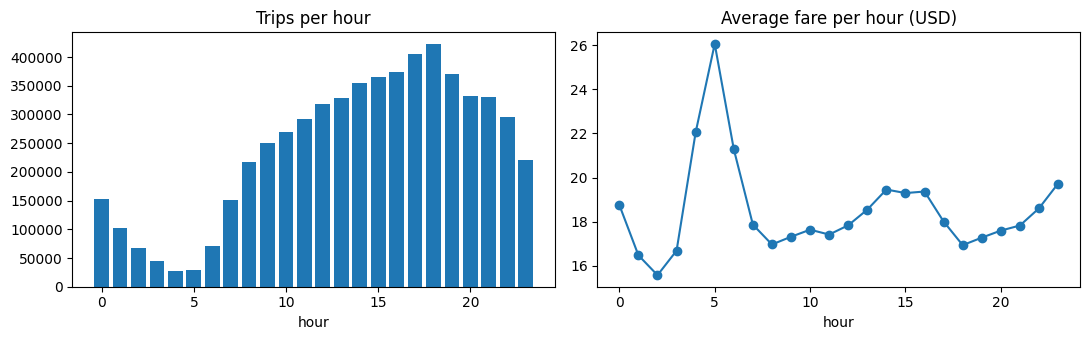

In [18]:
import matplotlib.pyplot as plt
by_hour = spark.sql('''
    SELECT hour, COUNT(*) AS trips, ROUND(AVG(fare_amount), 2) AS avg_fare
    FROM train GROUP BY hour ORDER BY hour''').toPandas()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].bar(by_hour['hour'], by_hour['trips']); ax[0].set_title('Trips per hour'); ax[0].set_xlabel('hour')
ax[1].plot(by_hour['hour'], by_hour['avg_fare'], marker='o'); ax[1].set_title('Average fare per hour (USD)'); ax[1].set_xlabel('hour')
plt.tight_layout(); plt.savefig(str(BASE / 'results' / 'eda_hourly.png'), dpi=150); plt.show()

In [19]:
top_zones = spark.sql('''
    SELECT z.Zone, z.Borough, COUNT(*) AS trips, ROUND(AVG(t.fare_amount), 2) AS avg_fare
    FROM train t JOIN zones z ON t.PULocationID = z.LocationID
    GROUP BY z.Zone, z.Borough ORDER BY trips DESC LIMIT 10''').toPandas()
top_zones

,Zone,Borough,trips,avg_fare
0,Midtown Center,Manhattan,290554,15.68
1,Upper East Side South,Manhattan,285705,12.53
2,JFK Airport,Queens,267947,61.94
3,Upper East Side North,Manhattan,265735,12.97
4,Midtown East,Manhattan,217634,15.29
5,Times Sq/Theatre District,Manhattan,208888,18.03
6,Penn Station/Madison Sq West,Manhattan,208763,16.35
7,Lincoln Square East,Manhattan,201216,13.60
8,LaGuardia Airport,Queens,188437,41.66
9,Midtown North,Manhattan,177320,15.46


In [20]:
dist_stats = train.select('trip_distance', 'fare_amount').summary().toPandas()
dist_stats

,summary,trip_distance,fare_amount
0,count,5791911,5791911
1,mean,3.196991868486818,18.161398614377134
2,stddev,4.169950669898147,15.783671243461082
3,min,0.1,3.0
4,25%,1.01,8.6
5,50%,1.7,12.8
6,75%,3.1,19.8
7,max,79.47,200.0


## 2. Scalability and partition pruning
Time the same aggregation on 1, 2 and 3 months of the raw zone, and compare a partition-pruned query with a full scan.
(Local mode on one machine: absolute numbers are small; report the trend and explain how a real cluster would scale.)

In [21]:
import time, pandas as pd
raw_zone = str(LAKE / 'raw_zone' / 'yellow_trips')
months = [f'{YEAR}-{m:02d}' for m in MONTHS]

def timed(fn, repeats=3):
    """Median wall-clock time of several runs (the first run in a session is slower: JVM warm-up, file listing, caching)."""
    ts = []
    for _ in range(repeats):
        t0 = time.time(); fn(); ts.append(time.time() - t0)
    return round(sorted(ts)[len(ts) // 2], 2)

def agg(subset):
    d = spark.read.parquet(raw_zone).filter(F.col('pickup_month').isin(subset))
    return d.groupBy('PULocationID').agg(F.avg('fare_amount'), F.count('*')).count()

agg(months)   # warm-up run, result discarded
rows = []
for k in range(1, len(months) + 1):
    n = spark.read.parquet(raw_zone).filter(F.col('pickup_month').isin(months[:k])).count()
    rows.append({'months': k, 'rows': n, 'median_seconds': timed(lambda: agg(months[:k]))})
scal = pd.DataFrame(rows)
scal.to_csv(str(BASE / 'results' / 'spark_scalability.csv'), index=False)
scal

,months,rows,median_seconds
0,1,2964617,0.57
1,2,5972150,1.07
2,3,9554757,0.78


In [22]:
lake = spark.read.parquet(raw_zone)
t_prune = timed(lambda: lake.filter(F.col('pickup_month') == months[0]).agg(F.avg('fare_amount')).collect())
t_full = timed(lambda: lake.filter(F.col('tpep_pickup_datetime') < f'{YEAR}-02-01').agg(F.avg('fare_amount')).collect())
print(f'partition-pruned: {t_prune:.2f}s | filter on non-partition column: {t_full:.2f}s (median of 3 runs)')

partition-pruned: 0.34s | filter on non-partition column: 0.98s (median of 3 runs)


## 3. Export modelling sample (model zone)
Random fractions of each split are converted to pandas-friendly Parquet. Increase `FRAC` if your machine has enough RAM.

In [23]:
FRAC = {'train': 0.20, 'val': 0.20, 'test': 0.20}
mz = LAKE / 'model_zone'
for name, d in [('train', train), ('val', val), ('test', test)]:
    s = d.drop('pickup_month').sample(False, FRAC[name], seed=42)
    s.write.mode('overwrite').parquet(str(mz / name))
    print(name, 'sample rows:', spark.read.parquet(str(mz / name)).count())

train sample rows: 1159653
val sample rows: 248560
test sample rows: 248510


## Notes for the report
- Describe the architecture diagram, the zones (raw / curated / model) and why Parquet + Spark were chosen.
- Include the scalability table and the pruning comparison, and state their limits (single machine).
- Next: Stage 4, baseline models.

In [24]:
spark.stop()  # free memory before training the neural network

## Shared helper code (from `src/utils.py`)

In [25]:
"""Shared helpers for stages 4-6 (data loading, scaling, model building, evaluation, logging)."""
import json, time
from pathlib import Path
import numpy as np
import pandas as pd

BASE = Path('..') if Path('../data').exists() else Path('.')
LAKE = BASE / 'data' / 'lake'
MODEL_ZONE = LAKE / 'model_zone'
MODELS = BASE / 'models'
RESULTS = BASE / 'results'
for _p in (MODELS, RESULTS):
    _p.mkdir(parents=True, exist_ok=True)

NUM_COLS = ['trip_distance', 'passenger_count', 'hour', 'dow', 'is_weekend', 'hour_sin', 'hour_cos']
CAT_COLS = ['PULocationID', 'DOLocationID', 'RatecodeID']
TARGET = 'fare_amount'
VOCAB = {'PULocationID': 266, 'DOLocationID': 266, 'RatecodeID': 8}
SEED = 42
LOG_FILE = RESULTS / 'experiment_log.csv'


def load_split(name):
    """Load a split exported by Stage 3 (train / val / test) as a pandas DataFrame."""
    return pd.read_parquet(MODEL_ZONE / name)


def fit_scaler(train_df):
    """Mean/std computed on TRAIN only (avoids leakage)."""
    stats = {c: (float(train_df[c].mean()), float(train_df[c].std() or 1.0)) for c in NUM_COLS}
    (MODELS / 'scaler.json').write_text(json.dumps(stats))
    return stats


def make_xy(df, scaler, cfg):
    num = np.column_stack([(df[c].values - scaler[c][0]) / scaler[c][1] for c in NUM_COLS]).astype('float32')
    x = {'num': num}
    if cfg.get('embed'):
        for c in CAT_COLS:
            x[c] = df[c].values.astype('int32').reshape(-1, 1)
    y = df[TARGET].values.astype('float32')
    if cfg.get('log_target'):
        y = np.log1p(y)
    return x, y


def build_model(cfg, n_num=len(NUM_COLS)):
    import tensorflow as tf
    from tensorflow.keras import layers, Model
    num_in = layers.Input(shape=(n_num,), name='num')
    inputs, feats = [num_in], [num_in]
    if cfg.get('embed'):
        for c in CAT_COLS:
            i = layers.Input(shape=(1,), name=c, dtype='int32')
            inputs.append(i)
            e = layers.Flatten()(layers.Embedding(VOCAB[c], cfg.get('embed_dim', 8))(i))
            feats.append(e)
    x = layers.Concatenate()(feats) if len(feats) > 1 else num_in
    for units in cfg['hidden']:
        x = layers.Dense(units, activation='relu')(x)
        if cfg.get('dropout', 0) > 0:
            x = layers.Dropout(cfg['dropout'])(x)
    out = layers.Dense(1)(x)
    model = Model(inputs, out)
    loss = tf.keras.losses.Huber() if cfg.get('loss') == 'huber' else 'mse'
    model.compile(optimizer=tf.keras.optimizers.Adam(cfg.get('lr', 1e-3)), loss=loss, metrics=['mae'])
    return model


def metrics(y_true, y_pred):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    return {'mae': float(mean_absolute_error(y_true, y_pred)),
            'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
            'r2': float(r2_score(y_true, y_pred))}


def predict_dollars(model, x, cfg):
    p = model.predict(x, batch_size=4096, verbose=0).ravel()
    return np.expm1(p) if cfg.get('log_target') else p


def log_result(name, kind, cfg, split_metrics, train_seconds=None, n_params=None, split='val'):
    row = {'name': name, 'kind': kind, 'split': split, **split_metrics,
           'train_seconds': train_seconds, 'n_params': n_params,
           'config': json.dumps(cfg, sort_keys=True), 'timestamp': pd.Timestamp.now().isoformat(timespec='seconds')}
    df = pd.DataFrame([row])
    df.to_csv(LOG_FILE, mode='a', header=not LOG_FILE.exists(), index=False)
    return row


def train_eval_nn(name, cfg, train, val, scaler, verbose=0):
    """Train a Keras model with early stopping, evaluate on VALIDATION in dollars, log the result."""
    import tensorflow as tf
    tf.keras.utils.set_random_seed(SEED)
    xtr, ytr = make_xy(train, scaler, cfg)
    xva, _ = make_xy(val, scaler, cfg)
    model = build_model(cfg)
    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    yva_t = np.log1p(val[TARGET].values) if cfg.get('log_target') else val[TARGET].values
    t0 = time.time()
    hist = model.fit(xtr, ytr, validation_data=(xva, yva_t.astype('float32')),
                     epochs=cfg.get('epochs', 20), batch_size=cfg.get('batch_size', 1024),
                     callbacks=[es], verbose=verbose)
    secs = time.time() - t0
    m = metrics(val[TARGET].values, predict_dollars(model, xva, cfg))
    log_result(name, 'neural_network', cfg, m, secs, model.count_params(), 'val')
    return model, hist, m


# Stage 4: Baseline Models
Establish reference performance before improving the neural network.
Metrics: MAE and RMSE (USD) and R2, evaluated on the **validation** set.

In [26]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

train, val = load_split('train'), load_split('val')
scaler = fit_scaler(train)
print(train.shape, val.shape)
train.head()

(1159653, 11) (248560, 11)


,trip_distance,passenger_count,hour,dow,is_weekend,hour_sin,hour_cos,PULocationID,DOLocationID,RatecodeID,fare_amount
0,1.30,1,0,4,0,0.0,1.0,234,233,1,7.9
1,0.77,1,0,4,0,0.0,1.0,186,68,1,6.5
2,0.83,4,0,4,0,0.0,1.0,186,230,1,6.5
3,2.22,1,0,4,0,0.0,1.0,43,145,1,13.5
4,0.80,1,0,4,0,0.0,1.0,161,237,1,5.8


## 1. Naive baseline (predict the mean fare)

In [27]:
m = metrics(val[TARGET], np.full(len(val), train[TARGET].mean()))
log_result('mean_predictor', 'naive', {}, m)
m

{'mae': 10.562641605908981,
 'rmse': 15.747388007723313,
 'r2': -2.773544727219246e-09}

## 2. Linear regression (traditional model)

In [28]:
from sklearn.linear_model import LinearRegression
lin = LinearRegression().fit(train[NUM_COLS], train[TARGET])
m = metrics(val[TARGET], lin.predict(val[NUM_COLS]))
log_result('linear_regression', 'traditional', {'features': NUM_COLS}, m)
m

{'mae': 2.465811888968385, 'rmse': 4.093381132776444, 'r2': 0.9324310280389417}

## 3. Random forest (traditional non-linear model, trained on a subsample for speed)

In [29]:
import time
from sklearn.ensemble import RandomForestRegressor
feats = NUM_COLS + CAT_COLS
sub = train.sample(min(200_000, len(train)), random_state=SEED)
t0 = time.time()
rf = RandomForestRegressor(n_estimators=60, max_depth=18, n_jobs=-1, random_state=SEED).fit(sub[feats], sub[TARGET])
secs = time.time() - t0
m = metrics(val[TARGET], rf.predict(val[feats]))
log_result('random_forest', 'traditional', {'n_estimators': 60, 'max_depth': 18, 'train_rows': len(sub)}, m, secs)
m

{'mae': 1.692806504210003, 'rmse': 2.736931869526379, 'r2': 0.9697927689339381}

## 4. Baseline neural network (MLP, numeric features only, no embeddings)
This is the starting point that Stage 5 improves.

In [30]:
BASE_CFG = {'embed': False, 'hidden': [64, 32], 'dropout': 0.0, 'lr': 1e-3, 'batch_size': 1024, 'epochs': 15}
model, hist, m = train_eval_nn('nn_baseline', BASE_CFG, train, val, scaler, verbose=1)
m

Epoch 1/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 63.6387 - mae: 3.8739 - val_loss: 14.2134 - val_mae: 2.0825
Epoch 2/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 14.2834 - mae: 2.0949 - val_loss: 13.7767 - val_mae: 2.0457
Epoch 3/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 13.9585 - mae: 2.0790 - val_loss: 13.5999 - val_mae: 2.0252
Epoch 4/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 13.7366 - mae: 2.0673 - val_loss: 13.4473 - val_mae: 2.0109
Epoch 5/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 13.5873 - mae: 2.0578 - val_loss: 13.3461 - val_mae: 2.0035
Epoch 6/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 13.5178 - mae: 2.0521 - val_loss: 13.3062 - val_mae: 1.9990
Epoch 7/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 13.4834 - mae: 2.0488 - val_loss: 13.2817 - val_mae: 1.9967
Epoch 8/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 13.4605 - mae: 2.0465 - val_loss: 13.2665 - val_mae: 1.9952
Epoch 9/15
1133/1133 ━━━

{'mae': 1.9874933457619741, 'rmse': 3.632492061449281, 'r2': 0.946790118459047}

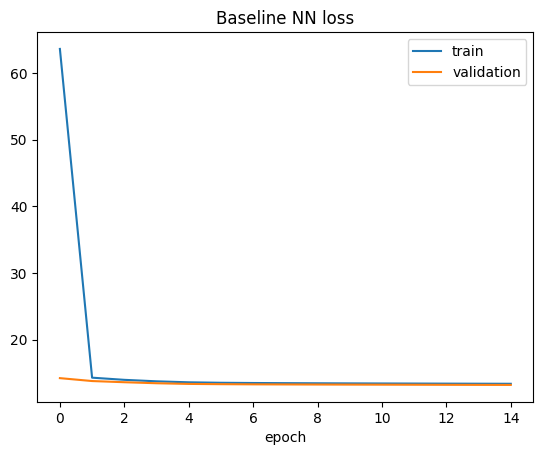

,name,kind,mae,rmse,r2
0,mean_predictor,naive,10.562642,15.747388,-2.773545e-09
1,linear_regression,traditional,2.465812,4.093381,9.324310e-01
2,random_forest,traditional,1.692807,2.736932,9.697928e-01
3,nn_baseline,neural_network,1.987493,3.632492,9.467901e-01


In [31]:
plt.plot(hist.history['loss'], label='train'); plt.plot(hist.history['val_loss'], label='validation')
plt.title('Baseline NN loss'); plt.xlabel('epoch'); plt.legend()
plt.savefig(str(RESULTS / 'baseline_loss.png'), dpi=150); plt.show()
pd.read_csv(LOG_FILE)[['name', 'kind', 'mae', 'rmse', 'r2']]

Next: Stage 5, systematic experiments to improve the neural network.

# Stage 5: Iterative Experiments
Each experiment changes **one idea** relative to the previous best, so the effect is attributable.
All results are logged to `results/experiment_log.csv` and compared on the validation set.

| Experiment | Change | Category |
|---|---|---|
| Exp1 | wider/deeper network, dropout | architecture + hyperparameters |
| Exp2 | learning-rate / batch-size change | hyperparameters |
| Exp3 | zone and rate-code **embeddings** | architecture / data representation |
| Exp4 | log-transformed target + Huber loss | data preparation |
| Exp5 | combine the best ideas | final candidate |

In [32]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

train, val = load_split('train'), load_split('val')
scaler = fit_scaler(train)

BASE_CFG = {'embed': False, 'hidden': [64, 32], 'dropout': 0.0, 'lr': 1e-3, 'batch_size': 1024, 'epochs': 15}
experiments = {}

## Exp1: capacity (architecture)

In [33]:
cfg = {**BASE_CFG, 'hidden': [256, 128, 64], 'dropout': 0.1}
experiments['nn_exp1_capacity'] = cfg
_, h, m = train_eval_nn('nn_exp1_capacity', cfg, train, val, scaler); m

{'mae': 1.9893251265880951,
 'rmse': 3.6533938987942163,
 'r2': 0.946176003357005}

## Exp2: optimisation hyperparameters

In [34]:
cfg = {**experiments['nn_exp1_capacity'], 'lr': 3e-4, 'batch_size': 2048, 'epochs': 25}
experiments['nn_exp2_hyperparams'] = cfg
_, h, m = train_eval_nn('nn_exp2_hyperparams', cfg, train, val, scaler); m

{'mae': 1.9945645291219003,
 'rmse': 3.6157072772787826,
 'r2': 0.9472807199167562}

## Exp3: embeddings for pickup zone, dropoff zone and rate code

In [35]:
cfg = {**BASE_CFG, 'embed': True, 'embed_dim': 8, 'hidden': [256, 128, 64], 'dropout': 0.1}
experiments['nn_exp3_embeddings'] = cfg
_, h, m = train_eval_nn('nn_exp3_embeddings', cfg, train, val, scaler); m

{'mae': 1.5020786379493236,
 'rmse': 2.432674552553263,
 'r2': 0.9761355753345812}

## Exp4: target transformation and robust loss (data-preparation change)

In [36]:
cfg = {**experiments['nn_exp3_embeddings'], 'log_target': True, 'loss': 'huber'}
experiments['nn_exp4_logtarget_huber'] = cfg
_, h, m = train_eval_nn('nn_exp4_logtarget_huber', cfg, train, val, scaler); m

{'mae': 1.6712690186494412,
 'rmse': 2.8163663081985306,
 'r2': 0.9680139048429903}

## Exp5: combine the best ideas (edit this cell after seeing Exp1-4 results)

In [37]:
cfg = {**experiments['nn_exp4_logtarget_huber'], 'lr': 5e-4, 'batch_size': 2048, 'epochs': 30, 'embed_dim': 12}
experiments['nn_exp5_combined'] = cfg
_, h, m = train_eval_nn('nn_exp5_combined', cfg, train, val, scaler); m

{'mae': 1.5957049936448644,
 'rmse': 2.6572680490352054,
 'r2': 0.9715256594019264}

## Comparison of all runs (validation set)

In [38]:
log = pd.read_csv(LOG_FILE)
log = log[log['split'] == 'val'].drop_duplicates('name', keep='last')
log = log[['name', 'kind', 'mae', 'rmse', 'r2', 'train_seconds', 'n_params']].sort_values('rmse')
log.to_csv(str(RESULTS / 'comparison_table.csv'), index=False)
log

,name,kind,mae,rmse,r2,train_seconds,n_params
6,nn_exp3_embeddings,neural_network,1.502079,2.432675,9.761356e-01,280.868475,53729.0
8,nn_exp5_combined,neural_network,1.595705,2.657268,9.715257e-01,334.103329,58961.0
2,random_forest,traditional,1.692807,2.736932,9.697928e-01,40.895416,NaN
7,nn_exp4_logtarget_huber,neural_network,1.671269,2.816366,9.680139e-01,128.587353,53729.0
5,nn_exp2_hyperparams,neural_network,1.994565,3.615707,9.472807e-01,417.343345,43265.0
3,nn_baseline,neural_network,1.987493,3.632492,9.467901e-01,79.388497,2625.0
4,nn_exp1_capacity,neural_network,1.989325,3.653394,9.461760e-01,127.451348,43265.0
1,linear_regression,traditional,2.465812,4.093381,9.324310e-01,NaN,NaN
0,mean_predictor,naive,10.562642,15.747388,-2.773545e-09,NaN,NaN


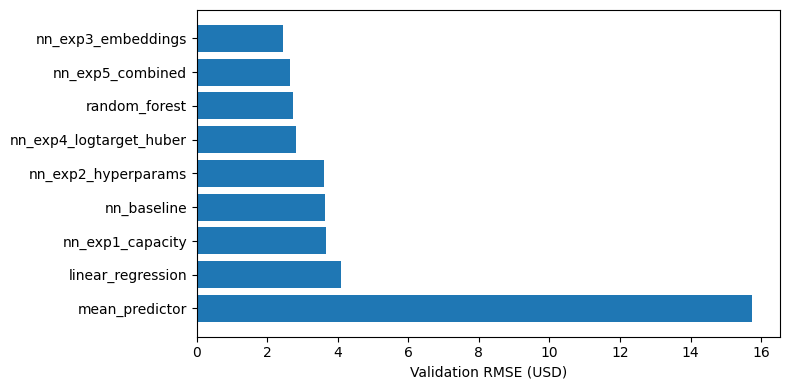

In [39]:
plt.figure(figsize=(8, 4))
plt.barh(log['name'], log['rmse']); plt.xlabel('Validation RMSE (USD)'); plt.gca().invert_yaxis()
plt.tight_layout(); plt.savefig(str(RESULTS / 'comparison_rmse.png'), dpi=150); plt.show()

## Notes for the report
For every experiment write: what changed, why you expected it to help, what happened (numbers) and what you learned.
If an experiment made things worse, say so; that is useful evidence.

# Stage 6: Final Model and Test Evaluation
The best neural-network configuration (lowest validation RMSE in the log) is retrained and evaluated **once** on the untouched test set, next to the baselines.

In [40]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

import json, time
train, val, test = load_split('train'), load_split('val'), load_split('test')
scaler = fit_scaler(train)

log = pd.read_csv(LOG_FILE)
nn = log[(log['kind'] == 'neural_network') & (log['split'] == 'val')].drop_duplicates('name', keep='last')
best = nn.sort_values('rmse').iloc[0]
best_cfg = json.loads(best['config'])
print('Selected:', best['name'], '| val RMSE', round(best['rmse'], 3))
best_cfg

Selected: nn_exp3_embeddings | val RMSE 2.433


{'batch_size': 1024,
 'dropout': 0.1,
 'embed': True,
 'embed_dim': 8,
 'epochs': 15,
 'hidden': [256, 128, 64],
 'lr': 0.001}

## 1. Retrain the selected configuration

In [41]:
model, hist, m_val = train_eval_nn('nn_final', best_cfg, train, val, scaler, verbose=1)
model.save(str(MODELS / 'final_model.keras'))
m_val

Epoch 1/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - loss: 28.6619 - mae: 2.8818 - val_loss: 8.2246 - val_mae: 1.7280
Epoch 2/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - loss: 10.8982 - mae: 2.1378 - val_loss: 7.0460 - val_mae: 1.6183
Epoch 3/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - loss: 9.9069 - mae: 2.0326 - val_loss: 6.4478 - val_mae: 1.5529
Epoch 4/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 9.4537 - mae: 1.9809 - val_loss: 6.3323 - val_mae: 1.5155
Epoch 5/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - loss: 9.1766 - mae: 1.9472 - val_loss: 6.4124 - val_mae: 1.5307
Epoch 6/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - loss: 8.9482 - mae: 1.9214 - val_loss: 6.2756 - val_mae: 1.5217
Epoch 7/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 8.7003 - mae: 1.8954 - val_loss: 6.3930 - val_mae: 1.5417
Epoch 8/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - loss: 8.5811 - mae: 1.8826 - val_loss: 5.9991 - val_mae: 1.5281
Epoch 9/15
1133/1133 ━

{'mae': 1.5020786379493236,
 'rmse': 2.432674552553263,
 'r2': 0.9761355753345812}

## 2. One-time test evaluation, final NN vs baselines

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

xte, _ = make_xy(test, scaler, best_cfg)
pred_nn = predict_dollars(model, xte, best_cfg)

lin = LinearRegression().fit(train[NUM_COLS], train[TARGET])
feats = NUM_COLS + CAT_COLS
sub = train.sample(min(200_000, len(train)), random_state=SEED)
rf = RandomForestRegressor(n_estimators=60, max_depth=18, n_jobs=-1, random_state=SEED).fit(sub[feats], sub[TARGET])

rows = {
    'Mean predictor': np.full(len(test), train[TARGET].mean()),
    'Linear regression': lin.predict(test[NUM_COLS]),
    'Random forest': rf.predict(test[feats]),
    'Neural network (final)': pred_nn,
}
res = pd.DataFrame({k: metrics(test[TARGET], v) for k, v in rows.items()}).T
res.to_csv(str(RESULTS / 'final_test_results.csv'))
log_result('nn_final_test', 'neural_network', best_cfg, metrics(test[TARGET], pred_nn), split='test')
res.round(3)

,mae,rmse,r2
Mean predictor,10.541,15.717,-0.000
Linear regression,2.471,4.120,0.931
Random forest,1.689,2.729,0.970
Neural network (final),1.503,2.435,0.976


## 3. Error analysis

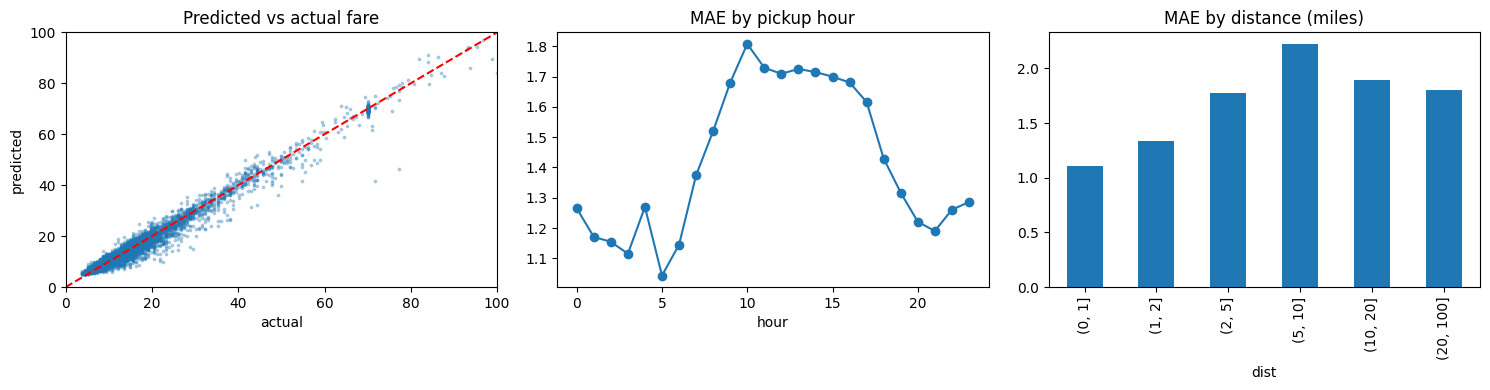

In [43]:
err = pd.DataFrame({'actual': test[TARGET].values, 'pred': pred_nn, 'hour': test['hour'].values, 'dist': test['trip_distance'].values})
err['abs_err'] = (err['actual'] - err['pred']).abs()

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
idx = err.sample(min(5000, len(err)), random_state=1)
ax[0].scatter(idx['actual'], idx['pred'], s=3, alpha=.3); ax[0].plot([0, 100], [0, 100], 'r--'); ax[0].set_xlim(0, 100); ax[0].set_ylim(0, 100)
ax[0].set_title('Predicted vs actual fare'); ax[0].set_xlabel('actual'); ax[0].set_ylabel('predicted')
err.groupby('hour')['abs_err'].mean().plot(ax=ax[1], marker='o'); ax[1].set_title('MAE by pickup hour')
err.groupby(pd.cut(err['dist'], [0, 1, 2, 5, 10, 20, 100]), observed=True)['abs_err'].mean().plot.bar(ax=ax[2]); ax[2].set_title('MAE by distance (miles)')
plt.tight_layout(); plt.savefig(str(RESULTS / 'final_error_analysis.png'), dpi=150); plt.show()

## 4. Inference cost

In [44]:
t0 = time.time(); _ = predict_dollars(model, xte, best_cfg); secs = time.time() - t0
print(f'{len(test):,} predictions in {secs:.2f}s ({len(test)/secs:,.0f} per second); parameters: {model.count_params():,}')

248,510 predictions in 0.67s (368,991 per second); parameters: 53,729


## Notes for the report (critical evaluation)
- Compare the NN with linear regression and random forest; say whether the extra complexity is justified.
- Discuss limitations: sampling, only 3 months, local Spark, no weather/traffic features, fares include rule-based components.
- Discuss scalability: Spark scales horizontally, the Keras model is trained on a sample on one machine; mention distributed training (e.g. Horovod, TF distribution strategies, Spark + Petastorm) as future work.

In [45]:
# Optional: download this stage's results (tables/figures) because the Colab session is temporary
try:
    import shutil
    from google.colab import files
    shutil.make_archive('/content/results_final', 'zip', str(BASE / 'results'))
    files.download('/content/results_final.zip')
except Exception as e:
    print('download skipped:', e)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>